## Step 7 — Implement baseline 3: Short temporal pooling ✅

#### Goal: Use multiple short time-series frames and combine their CNN features using mean pooling or max pooling.

#### This follows your proposal baseline:

#### “Short temporal pooling baseline – frame-wise feature extraction followed by mean or max pooling.”

###### A model that uses multiple images from different times and combines them using a simple pooling method.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
from PIL import Image
from tqdm import tqdm
import json
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [44]:
K = 8
STRATEGY = "uniform"
POOLING_TYPE = "mean"   # later you can change to "max"

K_FRAME_PATH = Path(f"../data/k_frames/K{K}_{STRATEGY}.csv")
NORMALIZATION_PATH = Path("../data/processed/normalization_stats.json")

df = pd.read_csv(K_FRAME_PATH)

print(df.head())
print(df.columns)
print(df.groupby(["split", "class_name"]).size())

  split  site_id class_name  label  K strategy  selected_frame_count  \
0  test       26     looted      1  8  uniform                     8   
1  test       27     looted      1  8  uniform                     8   
2  test       29     looted      1  8  uniform                     8   
3  test       30     looted      1  8  uniform                     8   
4  test       31     looted      1  8  uniform                     8   

   frame_1_index frame_1_name                                    frame_1_path  \
0              0  2016_01.jpg  ..\data\processed_images\looted\26\2016_01.jpg   
1              0  2016_01.jpg  ..\data\processed_images\looted\27\2016_01.jpg   
2              0  2016_01.jpg  ..\data\processed_images\looted\29\2016_01.jpg   
3              0  2016_01.jpg  ..\data\processed_images\looted\30\2016_01.jpg   
4              0  2016_01.jpg  ..\data\processed_images\looted\31\2016_01.jpg   

   ...                                    frame_5_path frame_6_index  \
0  ...  

In [45]:
with open(NORMALIZATION_PATH, "r") as f:
    norm_stats = json.load(f)

mean = norm_stats["mean"]
std = norm_stats["std"]

print("Mean:", mean)
print("Std:", std)

Mean: [0.6641249441448802, 0.5746265725068144, 0.42835551291561075]
Std: [0.17935859533908458, 0.1680383227926673, 0.17305869328805765]


In [46]:
train_df = df[df["split"] == "train"].reset_index(drop=True)
val_df = df[df["split"] == "val_1"].reset_index(drop=True)
test_df = df[df["split"] == "test"].reset_index(drop=True)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

print("Train class counts:")
print(train_df["label"].value_counts())

print("Validation class counts:")
print(val_df["label"].value_counts())

print("Test class counts:")
print(test_df["label"].value_counts())

Train: 524
Val: 18
Test: 61
Train class counts:
label
0    460
1     64
Name: count, dtype: int64
Validation class counts:
label
1    9
0    9
Name: count, dtype: int64
Test class counts:
label
0    35
1    26
Name: count, dtype: int64


In [47]:
image_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

In [48]:
class KFrameDataset(Dataset):
    def __init__(self, dataframe, k, transform=None):
        self.df = dataframe
        self.k = k
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        frames = []

        for i in range(1, self.k + 1):
            img_path = row[f"frame_{i}_path"]
            img = Image.open(img_path).convert("RGB")

            if self.transform:
                img = self.transform(img)

            frames.append(img)

        # shape: [K, 3, 224, 224]
        frames = torch.stack(frames, dim=0)

        label = torch.tensor(int(row["label"]), dtype=torch.long)

        return frames, label

In [49]:
BATCH_SIZE = 8

train_dataset = KFrameDataset(train_df, k=K, transform=image_transform)
val_dataset = KFrameDataset(val_df, k=K, transform=image_transform)
test_dataset = KFrameDataset(test_df, k=K, transform=image_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 66
Val batches: 3
Test batches: 8


In [50]:
frames, labels = next(iter(train_loader))

print(frames.shape)
print(labels.shape)

torch.Size([8, 8, 3, 224, 224])
torch.Size([8])


In [51]:
class TemporalPoolingCNN(nn.Module):
    def __init__(self, num_classes=2, pooling_type="mean"):
        super(TemporalPoolingCNN, self).__init__()

        self.pooling_type = pooling_type

        self.feature_extractor = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 224 -> 112

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 112 -> 56

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 56 -> 28

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 28 -> 14

            nn.AdaptiveAvgPool2d((1, 1))  # [B*K, 128, 1, 1]
        )

        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        # x shape: [B, K, 3, 224, 224]
        batch_size, k, c, h, w = x.shape

        # combine batch and time dimensions
        x = x.view(batch_size * k, c, h, w)

        # extract CNN features for every frame
        features = self.feature_extractor(x)

        # shape: [B*K, 128]
        features = features.view(batch_size, k, 128)

        # temporal pooling
        if self.pooling_type == "mean":
            pooled = torch.mean(features, dim=1)

        elif self.pooling_type == "max":
            pooled, _ = torch.max(features, dim=1)

        else:
            raise ValueError("pooling_type must be 'mean' or 'max'")

        output = self.classifier(pooled)

        return output

In [52]:
model = TemporalPoolingCNN(
    num_classes=2,
    pooling_type=POOLING_TYPE
).to(device)

print(model)

TemporalPoolingCNN(
  (feature_extractor): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(128, eps=1e-05, mome

In [53]:
class_counts = train_df["label"].value_counts().sort_index()
print(class_counts)

num_preserved = class_counts[0]
num_looted = class_counts[1]

total = num_preserved + num_looted

weight_preserved = total / (2 * num_preserved)
weight_looted = total / (2 * num_looted)

class_weights = torch.tensor(
    [weight_preserved, weight_looted],
    dtype=torch.float32
).to(device)

print("Class weights:", class_weights)

label
0    460
1     64
Name: count, dtype: int64
Class weights: tensor([0.5696, 4.0938])


In [54]:
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [55]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    for frames, labels in tqdm(dataloader):
        frames = frames.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(frames)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * frames.size(0)

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc

In [56]:
def evaluate(model, dataloader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for frames, labels in tqdm(dataloader):
            frames = frames.to(device)
            labels = labels.to(device)

            outputs = model(frames)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * frames.size(0)

            probs = torch.softmax(outputs, dim=1)[:, 1]
            preds = torch.argmax(outputs, dim=1)

            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)

    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)

    try:
        auc = roc_auc_score(all_labels, all_probs)
    except:
        auc = None

    cm = confusion_matrix(all_labels, all_preds)

    metrics = {
        "loss": epoch_loss,
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auc": auc,
        "confusion_matrix": cm
    }

    return metrics

In [57]:
EPOCHS = 10

RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

experiment_name = f"temporal_pooling_K{K}_{POOLING_TYPE}"

best_val_f1 = 0.0
best_model_path = RESULTS_DIR / f"{experiment_name}_best.pth"

history = []

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_metrics = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(
        f"Val Loss: {val_metrics['loss']:.4f} | "
        f"Val Acc: {val_metrics['accuracy']:.4f} | "
        f"Val Precision: {val_metrics['precision']:.4f} | "
        f"Val Recall: {val_metrics['recall']:.4f} | "
        f"Val F1: {val_metrics['f1']:.4f} | "
        f"Val AUC: {val_metrics['auc']}"
    )

    history.append({
        "epoch": epoch + 1,
        "K": K,
        "pooling_type": POOLING_TYPE,
        "train_loss": train_loss,
        "train_accuracy": train_acc,
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
        "val_f1": val_metrics["f1"],
        "val_auc": val_metrics["auc"]
    })

    if val_metrics["f1"] > best_val_f1:
        best_val_f1 = val_metrics["f1"]
        torch.save(model.state_dict(), best_model_path)
        print("Best model saved ✅")


Epoch 1/10


100%|██████████| 3/3 [00:02<00:00,  1.27it/s]


Train Loss: 0.6020 | Train Acc: 0.7691
Val Loss: 0.5484 | Val Acc: 0.7222 | Val Precision: 0.7000 | Val Recall: 0.7778 | Val F1: 0.7368 | Val AUC: 0.8765432098765432
Best model saved ✅

Epoch 2/10


100%|██████████| 3/3 [00:01<00:00,  1.93it/s]


Train Loss: 0.5578 | Train Acc: 0.7080
Val Loss: 0.6032 | Val Acc: 0.6111 | Val Precision: 0.6000 | Val Recall: 0.6667 | Val F1: 0.6316 | Val AUC: 0.8395061728395061

Epoch 3/10


...

Train Loss: 0.5218 | Train Acc: 0.7863
Val Loss: 0.6493 | Val Acc: 0.6111 | Val Precision: 0.6000 | Val Recall: 0.6667 | Val F1: 0.6316 | Val AUC: 0.5802469135802469

Epoch 9/10


100%|██████████| 3/3 [00:01<00:00,  2.04it/s]


Train Loss: 0.5068 | Train Acc: 0.7424
Val Loss: 0.5271 | Val Acc: 0.7222 | Val Precision: 0.6667 | Val Recall: 0.8889 | Val F1: 0.7619 | Val AUC: 0.7530864197530864
Best model saved ✅

Epoch 10/10


100%|██████████| 3/3 [00:01<00:00,  1.58it/s]


Train Loss: 0.5060 | Train Acc: 0.7824
Val Loss: 0.9118 | Val Acc: 0.4444 | Val Precision: 0.0000 | Val Recall: 0.0000 | Val F1: 0.0000 | Val AUC: 0.6296296296296297


In [58]:
history_df = pd.DataFrame(history)
history_df.to_csv(RESULTS_DIR / f"{experiment_name}_history.csv", index=False)

history_df

,epoch,K,pooling_type,train_loss,train_accuracy,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_auc
0,1,8,mean,0.602037,0.769084,0.548365,0.722222,0.700000,0.777778,0.736842,0.876543
1,2,8,mean,0.557768,0.708015,0.603170,0.611111,0.600000,0.666667,0.631579,0.839506
2,3,8,mean,0.558898,0.746183,0.572209,0.666667,0.600000,1.000000,0.750000,0.753086
3,4,8,mean,0.572552,0.709924,0.576385,0.666667,0.600000,1.000000,0.750000,0.654321
4,5,8,mean,0.527680,0.736641,0.971886,0.500000,0.000000,0.000000,0.000000,0.666667
5,6,8,mean,0.539199,0.761450,0.795123,0.500000,0.500000,0.111111,0.181818,0.728395
6,7,8,mean,0.467217,0.809160,0.961573,0.500000,0.500000,1.000000,0.666667,0.580247
7,8,8,mean,0.521761,0.786260,0.649332,0.611111,0.600000,0.666667,0.631579,0.580247
8,9,8,mean,0.506818,0.742366,0.527062,0.722222,0.666667,0.888889,0.761905,0.753086
9,10,8,mean,0.506034,0.782443,0.911817,0.444444,0.000000,0.000000,0.000000,0.629630


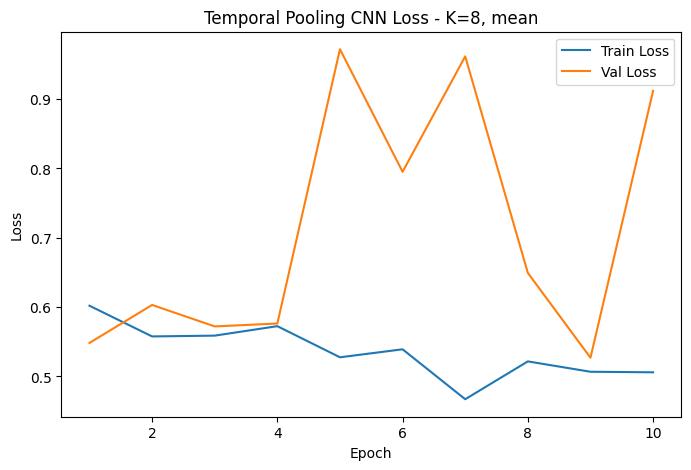

In [59]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Temporal Pooling CNN Loss - K={K}, {POOLING_TYPE}")
plt.legend()
plt.show()

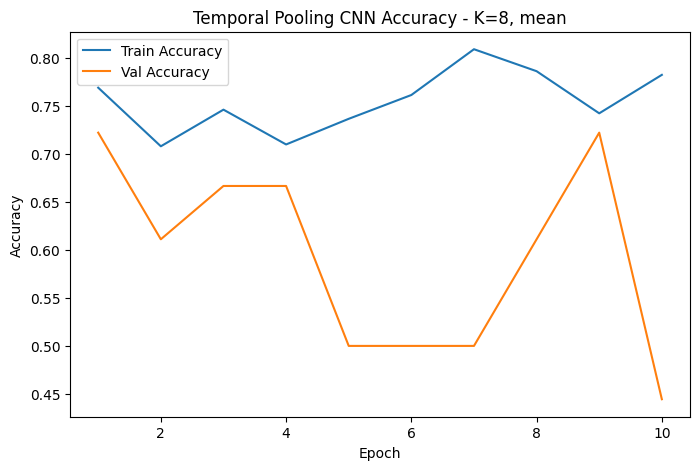

In [60]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_accuracy"], label="Train Accuracy")
plt.plot(history_df["epoch"], history_df["val_accuracy"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(f"Temporal Pooling CNN Accuracy - K={K}, {POOLING_TYPE}")
plt.legend()
plt.show()

In [61]:
best_model = TemporalPoolingCNN(
    num_classes=2,
    pooling_type=POOLING_TYPE
).to(device)

best_model.load_state_dict(torch.load(best_model_path, map_location=device))

test_metrics = evaluate(best_model, test_loader, criterion, device)

print("Test Results:")
print("Accuracy:", test_metrics["accuracy"])
print("Precision:", test_metrics["precision"])
print("Recall:", test_metrics["recall"])
print("F1:", test_metrics["f1"])
print("AUC:", test_metrics["auc"])
print("Confusion Matrix:")
print(test_metrics["confusion_matrix"])

100%|██████████| 8/8 [00:07<00:00,  1.00it/s]

Test Results:
Accuracy: 0.5901639344262295
Precision: 0.5116279069767442
Recall: 0.8461538461538461
F1: 0.6376811594202898
AUC: 0.6153846153846153
Confusion Matrix:
[[14 21]
 [ 4 22]]


In [62]:
test_result_df = pd.DataFrame([{
    "model": "temporal_pooling_cnn",
    "K": K,
    "strategy": STRATEGY,
    "pooling_type": POOLING_TYPE,
    "test_accuracy": test_metrics["accuracy"],
    "test_precision": test_metrics["precision"],
    "test_recall": test_metrics["recall"],
    "test_f1": test_metrics["f1"],
    "test_auc": test_metrics["auc"]
}])

test_result_df.to_csv(
    RESULTS_DIR / f"{experiment_name}_test_results.csv",
    index=False
)

test_result_df

,model,K,strategy,pooling_type,test_accuracy,test_precision,test_recall,test_f1,test_auc
0,temporal_pooling_cnn,8,uniform,mean,0.590164,0.511628,0.846154,0.637681,0.615385


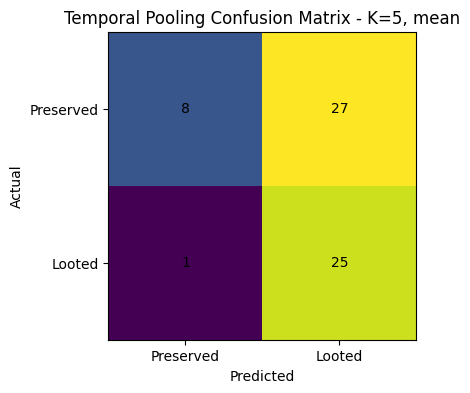

In [43]:
cm = test_metrics["confusion_matrix"]

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title(f"Temporal Pooling Confusion Matrix - K={K}, {POOLING_TYPE}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0, 1], ["Preserved", "Looted"])
plt.yticks([0, 1], ["Preserved", "Looted"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()